In [1]:
from pyrokinetics import Pyro, PyroScan
from pathlib import Path
import os
import numpy as np
import copy
import scipy

In [2]:
GYRO_DATA = Path("/mnt/data/Gyrokinetic_Simulations")

In [3]:
case = "MAST_MTM"

In [ ]:
cgyro_pyro_base_location = "/mnt/data/Downloads/zenodo/linear/cgyro/coll/nue030_sh07/n20/input.cgyro"
cgyro_pyro = Pyro(gk_file = cgyro_pyro_base_location)
cgyro_pyro.load_gk_output()

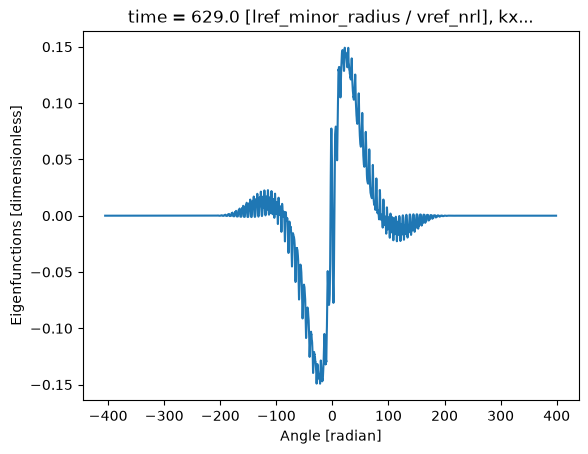

In [22]:
np.real(cgyro_pyro.gk_output["eigenfunctions"].sel(field = "phi").isel(time = -3)).plot()

In [ ]:
cgyro_pyroscan_base_location = GYRO_DATA / "CGYRO" / "Runs" / "MTMS" / case / "parameter_scan_ky"
cgyro_json = cgyro_pyroscan_base_location / "pyroscan.json"
cgyro_netcdf = cgyro_pyroscan_base_location / "pyroscan.nc"
cgyro_pyroscan = PyroScan(pyroscan_json=cgyro_json, load_base_pyro=True)
cgyro_pyroscan.load_gk_output(netcdf_file=cgyro_netcdf )

KeyboardInterrupt: 

In [10]:
cgyro_pyroscan.gk_output

<pyrokinetics.PyroScanGKOutput>
(Wraps <xarray.Dataset>) Size: 7MB
Dimensions:                (ky: 9, field: 3, theta: 8192, species: 2)
Coordinates:
  * field                  (field) <U4 48B 'phi' 'apar' 'bpar'
  * species                (species) <U8 64B 'electron' 'ion1'
  * ky                     (ky) float64 72B 0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9
  * theta                  (theta) float64 66kB -405.3 -405.2 ... 398.8 398.9
Data variables:
    growth_rate            (ky) float64 72B [vref_nrl/lref_minor_radius] 0.02...
    mode_frequency         (ky) float64 72B [vref_nrl/lref_minor_radius] -0.2...
    eigenfunctions         (ky, field, theta) complex128 4MB [] (6.2486542618...
    growth_rate_tolerance  (ky) float64 72B [] 8.054e-05 4.938e-08 ... 2.66
    particle               (ky, field, species) float64 432B [nref_electron·rhoref_pyro²·vref_nrl/lref_minor_radius²] ...
    heat                   (ky, field, species) float64 432B [nref_electron·rhoref_pyro²·tref_electron·vref_n

In [ ]:
GFS_pyroscan_base_location = GYRO_DATA / "GFTM" / "Runs" / "MTMS" / case

In [23]:
m = [3, 5, 7, 9]

numerical_settings = [
    "parameter_scan_gftm_nbasis_9_nxgrid_13_width_3.53",
    "parameter_scan_gftm_nbasis_13_nxgrid_19_width_4.282",
    "parameter_scan_gftm_nbasis_17_nxgrid_25_width_4.887",
    "parameter_scan_gftm_nbasis_21_nxgrid_31_width_5.416",
]

GFS_pyroscan_base_location = GYRO_DATA / "GFTM" / "Runs" / "MTMS" / case

for m_value, numerical_setting in zip(m, numerical_settings):

    gfs_location = GFS_pyroscan_base_location / numerical_setting
    gfs_json = gfs_location / "pyroscan.json"
    gfs_netcdf = gfs_location / "pyroscan.nc"

    print(f"Loading GFS pyroscan from {gfs_json}")

    gfs_pyroscan = PyroScan(
        pyroscan_json=gfs_json,
        load_base_pyro=True
    )

    gfs_pyroscan.load_gk_output(netcdf_file=gfs_netcdf)

    cgyro_dict[m_value] = gfs_pyroscan

Loading GFS pyroscan from /mnt/data/Gyrokinetic_Simulations/GFTM/Runs/MTMS/MAST_MTM/parameter_scan_gftm_nbasis_9_nxgrid_13_width_3.53/pyroscan.json
Loading GFS pyroscan from /mnt/data/Gyrokinetic_Simulations/GFTM/Runs/MTMS/MAST_MTM/parameter_scan_gftm_nbasis_13_nxgrid_19_width_4.282/pyroscan.json
Loading GFS pyroscan from /mnt/data/Gyrokinetic_Simulations/GFTM/Runs/MTMS/MAST_MTM/parameter_scan_gftm_nbasis_17_nxgrid_25_width_4.887/pyroscan.json
Loading GFS pyroscan from /mnt/data/Gyrokinetic_Simulations/GFTM/Runs/MTMS/MAST_MTM/parameter_scan_gftm_nbasis_21_nxgrid_31_width_5.416/pyroscan.json


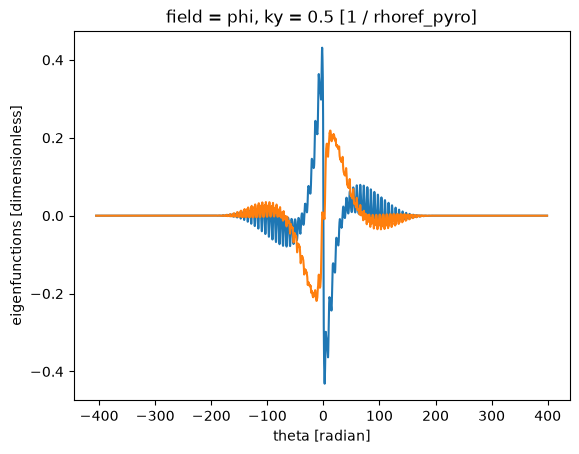

In [24]:
import numpy as np
np.real(cgyro_pyroscan.gk_output["eigenfunctions"].sel(ky=0.5).sel(field="phi")).plot()
np.imag(cgyro_pyroscan.gk_output["eigenfunctions"].sel(ky=0.5).sel(field="phi")).plot()


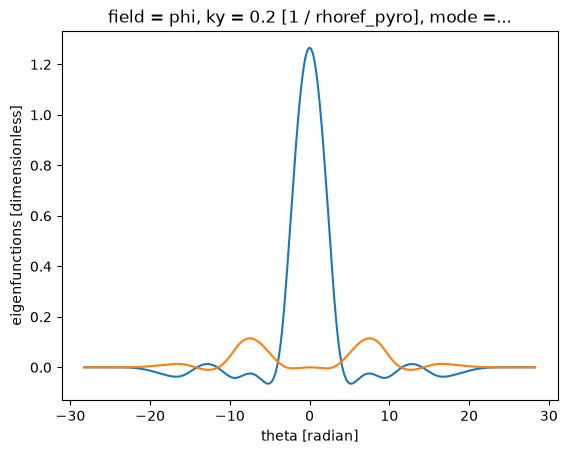

In [36]:
gfs_to_plot = cgyro_dict[5]
np.real(gfs_to_plot.gk_output["eigenfunctions"].sel(ky=0.2).sel(mode=0).sel(field="phi")).plot()
np.imag(gfs_to_plot.gk_output["eigenfunctions"].sel(ky=0.2).sel(mode=0).sel(field="phi")).plot()

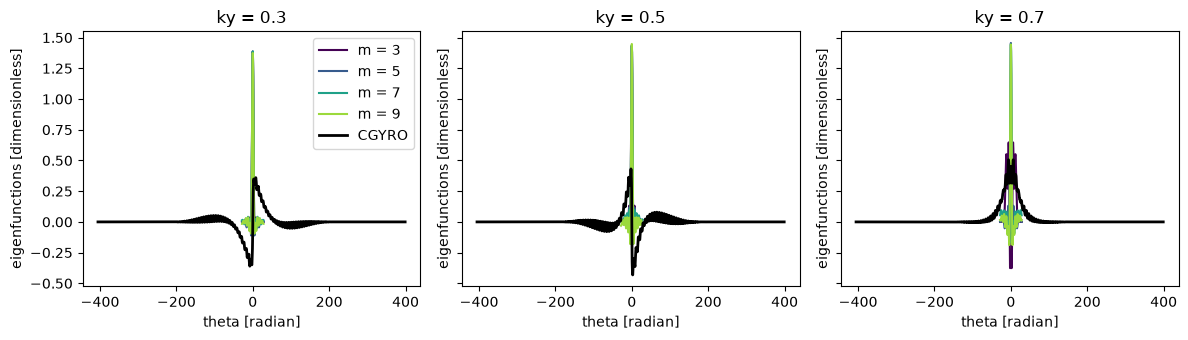

In [39]:
import numpy as np
import matplotlib.pyplot as plt

cols = dict(zip([3, 5, 7, 9], plt.cm.viridis(np.linspace(0, 0.85, 4))))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

for ax, ky in zip(axes, [0.3, 0.5, 0.7]):
    for m in [3, 5, 7, 9]:
        gfs_to_plot = cgyro_dict[m]
        e = gfs_to_plot.gk_output["eigenfunctions"].sel(ky=ky, method="nearest").sel(mode=0).sel(field="phi")
        np.real(e).plot(ax=ax, color=cols[m], label=f"m = {m}")

    e = cgyro_pyroscan.gk_output["eigenfunctions"].sel(ky=ky, method="nearest").sel(field="phi")
    np.real(e).plot(ax=ax, color="k", lw=2, label="CGYRO")
    ax.set_title(f"ky = {ky}")

axes[0].legend()
fig.tight_layout()

/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/pyrokinetics/src/pyrokinetics/gk_code/gftm.py:1250: RuntimeWarning: invalid value encountered in scalar divide
  phase = np.abs(phi_theta_star) / phi_theta_star
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/pint/facets/plain/quantity.py:984: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(self._magnitude, other_magnitude)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/pyrokinetics/src/pyrokinetics/gk_code/gftm.py:1250: RuntimeWarning: invalid value encountered in scalar divide
  phase = np.abs(phi_theta_star) / phi_theta_star
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/pint/facets/plain/quantity.py:984: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(self._magnitude, other_magnitude)


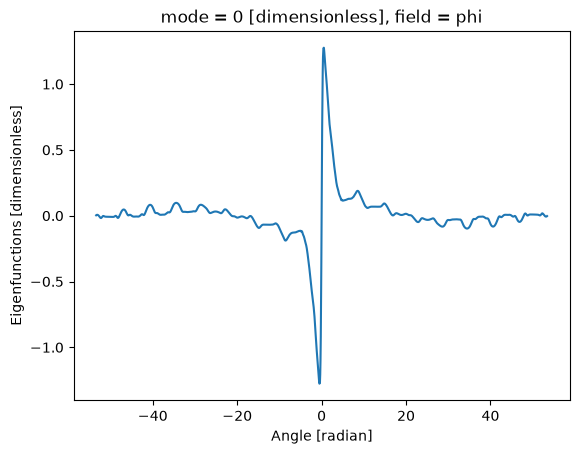

In [ ]:
iteration = 100
pyro_gs = Pyro(gk_file = f"/mnt/data/MTM_MODELS/MTM_2d_Model1/iteration_{iteration}/gs2.in")
pyro_gs.load_gk_output()
np.real(pyro_gs.gk_output["eigenfunctions"].isel(time=-1).sel(field="phi")).plot()
m_values = [3, 5]
pyro_m_values= {}
for m in m_values:
    pyro_m = Pyro(gk_file = f"/mnt/data/gftm_iterations/m{m}/iteration_{iteration}/input.gftm")
    pyro_m.load_gk_output()
    pyro_m_values[m] = pyro_m
    np.real(pyro_m.gk_output["eigenfunctions"].isel(mode=0).sel(field="phi")).plot()


In [57]:
pyro_m_values[3].gk_output["eigenfunctions"].isel(mode=0).sel(field="phi")

Magnitude,[nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj nan+nanj]
Units,dimensionless


/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/pyrokinetics/src/pyrokinetics/gk_code/gftm.py:1250: RuntimeWarning: invalid value encountered in scalar divide
  phase = np.abs(phi_theta_star) / phi_theta_star
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/pint/facets/plain/quantity.py:984: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(self._magnitude, other_magnitude)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/pyrokinetics/src/pyrokinetics/gk_code/gftm.py:1250: RuntimeWarning: invalid value encountered in scalar divide
  phase = np.abs(phi_theta_star) / phi_theta_star
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analysis/.venv/lib/python3.14/site-packages/pint/facets/plain/quantity.py:984: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(self._magnitude, other_magnitude)
/home/Felix/Documents/Physics_Work/Project_Codes/gftm_analys

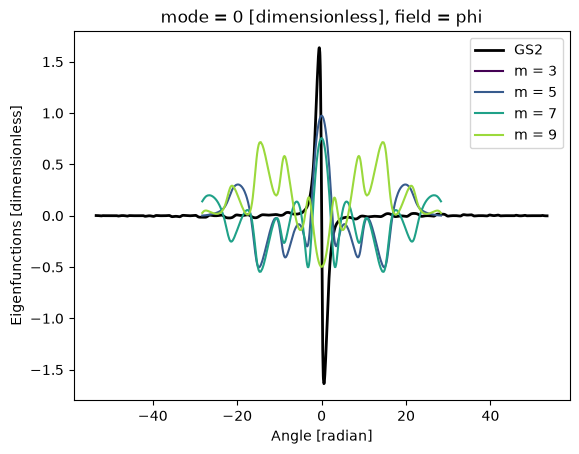

In [63]:
import matplotlib.pyplot as plt

cols = dict(zip([3, 5, 7, 9], plt.cm.viridis(np.linspace(0, 0.85, 4))))

iteration = 180
fig, ax = plt.subplots()

pyro_gs = Pyro(gk_file=f"/mnt/data/MTM_MODELS/MTM_2d_Model1/iteration_{iteration}/gs2.in")
pyro_gs.load_gk_output()
e_gs = np.real(pyro_gs.gk_output["eigenfunctions"].isel(time=-1).sel(field="phi"))
e_gs.plot(ax=ax, color="k", lw=2, label="GS2")

m_values = [3, 5, 7, 9]
for m in m_values:
    pyro_m = Pyro(gk_file=f"/mnt/data/gftm_iterations/m{m}/iteration_{iteration}/input.gftm")
    pyro_m.load_gk_output()
    e_m = np.real(pyro_m.gk_output["eigenfunctions"].isel(mode=0).sel(field="phi"))
    e_m.plot(ax=ax, color=cols[m], label=f"m = {m}")

ax.legend()